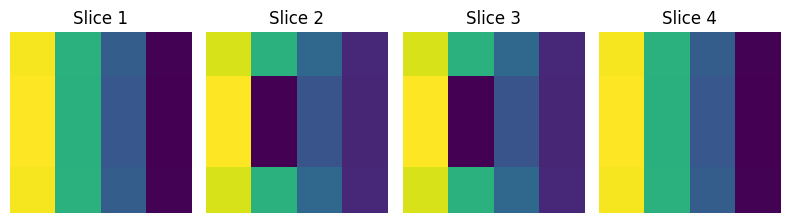

[[-5.0 ,1.0 ,0.0 ,0.0 ,1.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,1.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,],
[1.0 ,-4.0 ,1.0 ,0.0 ,0.0 ,1.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,1.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,],
[0.0 ,1.0 ,-4.0 ,1.0 ,0.0 ,0.0 ,1.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,1.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,0.0 ,],
[0.0 ,0.0 ,1.0 ,-5.0 ,0.

C:\Users\Rafael\AppData\Local\Temp\ipykernel_28236\4099190374.py:17: RuntimeWarning: overflow encountered in cast
  residuals[row] = residual


In [1]:
%run darcy_solver.ipynb

In [2]:
import os
os.chdir("..")
print(os.getcwd())

D:\repositories\PyFlowSolver


In [3]:
%run .\pyflowsolver\volumeManager.py
%run .\pyflowsolver\sparseArray.py
%run .\pyflowsolver\fastLaplacian.py
%run .\pyflowsolver\darcySolver.py

In [4]:
import porespy as ps

In [5]:
vol = ps.generators.blobs(shape=(20, 20, 20), blobiness=0.4, porosity=0.45)

In [6]:
import numpy as np
import scipy as sc

In [7]:
lab, n_lab = sc.ndimage.label(vol)

In [8]:
print(np.unique(lab[0,:,:]))
print(np.unique(lab[-1,:,:]))
print(np.unique(lab[:,0,:]))
print(np.unique(lab[:,-1,:]))
print(np.unique(lab[:,:,0]))
print(np.unique(lab[:,:,-1]))

[0 1]
[0 1 7]
[0 1 5]
[0 1 3]
[0 1 2 6 7]
[0 1 3 4]


In [9]:
con_vol = (lab==1)*100

In [10]:
con_vol = fast_laplacian_volume_generator(
    con_vol, 
    (1.2, 1.2, 1.2), 
    )

In [11]:
volume_manager = VolumeManager(con_vol)

In [12]:
sparse_A, sparse_b = volume_manager.get_sparse_system()

In [13]:
solver = DarcySolver()
solution = solver.solve(sparse_A, sparse_b)
raveled_solution = volume_manager.ravel_sparse_solution(solution)

In [14]:
import matplotlib.pyplot as plt

def plt_show(img, samples):
    num_slices = raveled_solution.shape[2]
    fig, axs = plt.subplots(3, 4, figsize=(8, 8))
    
    for i in range(num_slices//samples):
        slice_2d = img[i*samples, :, :]
        axs[0,i].imshow(slice_2d, cmap='viridis', origin='upper')
        axs[0,i].set_title(f'Slice {i + 1}')
        axs[0,i].axis('off')  # Turn off axis for better visualization
    
        slice_2d = img[:, i*samples, :]
        axs[1,i].imshow(slice_2d, cmap='viridis', origin='upper')
        axs[1,i].set_title(f'Slice {i + 1 + 4}')
        axs[1,i].axis('off')  # Turn off axis for better visualization
    
        slice_2d = img[:, :, i*samples]
        axs[2,i].imshow(slice_2d, cmap='viridis', origin='upper')
        axs[2,i].set_title(f'Slice {i + 1 + 4}')
        axs[2,i].axis('off')  # Turn off axis for better visualization
    
    plt.tight_layout()
    plt.show()

IndexError: index 4 is out of bounds for axis 1 with size 4

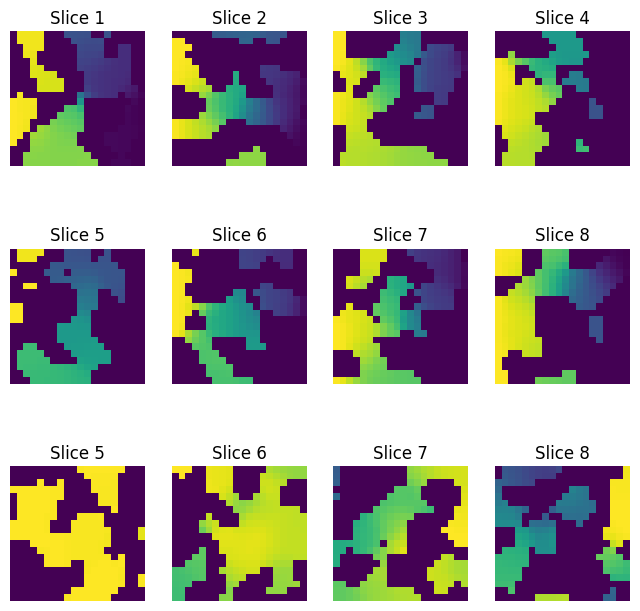

In [15]:
plt_show(raveled_solution, 4)

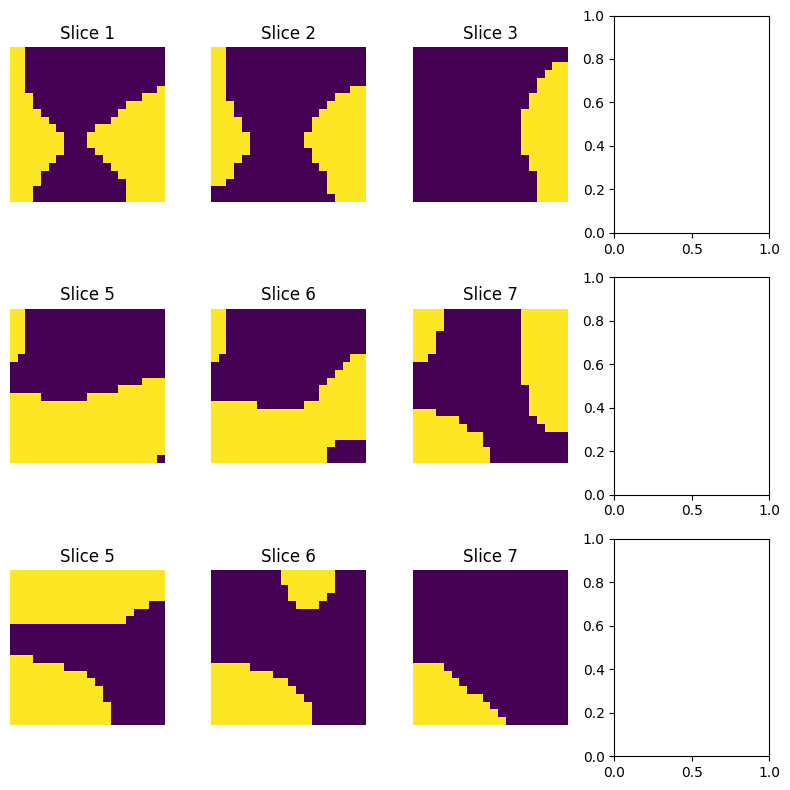

In [36]:
plt_show(vol, 4)

In [33]:
print(con_vol.min(), con_vol.max())
con_vol

0.36 3.2400002


array([[[0.36     , 0.36     , 0.36     , ..., 0.36     , 0.36     ,
         0.36     ],
        [0.36     , 0.36     , 0.36     , ..., 0.36     , 0.36     ,
         1.2035325],
        [0.36     , 0.36     , 0.36     , ..., 0.36     , 0.36     ,
         0.36     ],
        ...,
        [0.36     , 0.36     , 0.36     , ..., 0.36     , 0.36     ,
         0.36     ],
        [0.36     , 0.36     , 0.36     , ..., 0.36     , 0.36     ,
         0.36     ],
        [0.36     , 0.36     , 0.36     , ..., 0.36     , 0.36     ,
         0.36     ]],

       [[0.36     , 0.36     , 0.36     , ..., 0.36     , 0.36     ,
         0.36     ],
        [0.36     , 0.36     , 0.36     , ..., 0.36     , 0.36     ,
         0.36     ],
        [0.36     , 0.36     , 0.36     , ..., 0.36     , 0.36     ,
         0.36     ],
        ...,
        [0.36     , 0.36     , 0.36     , ..., 0.36     , 0.36     ,
         0.36     ],
        [0.36     , 0.36     , 0.36     , ..., 0.36     , 0.36     ,
   